>## Assignment

### Bayesian inference with conjugate priors (Beta–Binomial)

You observe binary data from a coin with unknown bias $\theta$.

**Dataset:** $n=20$ tosses with $k=14$ heads.

**Goal:** implement the full Bayesian update and posterior predictive checks in Python.

We choose the parameter $\theta \equiv P(\text{heads})$ -> probability of getting head.

**Tasks**

1) **Posterior update (uniform prior).**  
   Use $\theta\sim\mathrm{Beta}(1,1)$. Compute and plot the posterior $p(\theta\mid k,n)$ over $\theta\in[0,1]$.

2) **Posterior summary.**  
   Compute the posterior mean and variance. Verify them against the analytic formulas for a Beta distribution.

3) **Credible interval.**  
   Compute a 95\% credible interval for $\theta$. Use the exact Beta quantiles (e.g. via `scipy.stats.beta.ppf`).

4) **Posterior predictive.**  
   Compute the probability that the next toss is heads, and the probability of exactly 8 heads in the next 10 tosses.  
   (Hint: use the Beta–Binomial predictive distribution.)

5) **Informative prior.**  
   Repeat (1)–(4) with $\theta\sim\mathrm{Beta}(8,4)$ and compare the posterior and predictive results to the uniform-prior case.

**Deliverables**

- One figure showing the two posteriors (uniform vs informative prior).  
- One short table summarizing posterior mean/variance and the 95\% credible interval for both priors.  
- One paragraph interpreting how the prior influences the posterior and predictive probabilities.

*Tip:* For a Beta $(\alpha,\beta)$ posterior, the mean is $\alpha/(\alpha+\beta)$ and variance is $\alpha\beta/[(\alpha+\beta)^2(\alpha+\beta+1)]$.

> ## Solution: Lecture 8

1) **Posterior with $\mathrm{Beta}(1,1)$ prior**  
   The Binomial likelihood is proportional to $\theta^k(1-\theta)^{n-k}$.  
   The Beta prior is proportional to $\theta^{\alpha_0-1}(1-\theta)^{\beta_0-1}$.  
   Multiply them and collect exponents:  

   $$p(\theta\mid k,n) \propto \theta^{k+\alpha_0-1}(1-\theta)^{n-k+\beta_0-1}.$$
  
   With $\alpha_0=1,\beta_0=1$, this gives

   $$p(\theta\mid k,n) \sim \mathrm{Beta}(1+k,\,1+n-k)=\mathrm{Beta}(15,7).$$

2) **Posterior mean and variance**  
   For a $\mathrm{Beta}(\alpha,\beta)$ distribution:  

   $$\mathbb E[\theta]=\frac{\alpha}{\alpha+\beta},\qquad
   \mathrm{Var}(\theta)=\frac{\alpha\beta}{(\alpha+\beta)^2(\alpha+\beta+1)}.$$  
   
   Plug in $\alpha=15,\beta=7$ to get the numerical values.

3) **95\% credible interval**  
   A 95\% central credible interval is given by the 2.5\% and 97.5\% quantiles of the Beta posterior.  
   Compute $[q_{0.025},q_{0.975}]$ using `scipy.stats.beta.ppf`.

4) **Posterior predictive**  
   The predictive probability for the next toss is  ($H = $ "the next toss is head")

   We know $P(H\mid\theta) = \theta$ (from binomial distr) is the probability of getting head on the next toss. But we do not know what $\theta$ is. Instead, we have the posterior $p(\theta\mid k,n)$. We average over all $\theta$.

   $$P(H\mid k,n)=\int P(H\mid \theta) p(\theta\mid k,n) \mathrm{d}\theta =  \int \theta p(\theta\mid k,n) \mathrm{d}\theta \mathbb = E[\theta]=\frac{15}{22}.$$ $$ 

   For $K$ heads in $m=10$ future tosses, the Beta-Binomial predictive is  

   $$P(K=8)=\binom{10}{8}\frac{B(\alpha+8,\beta+2)}{B(\alpha,\beta)},$$

   with $\alpha=15,\beta=7$.

5) **Informative prior $\mathrm{Beta}(8,4)$**  
   Repeat step (1):  

   $$p(\theta\mid k,n) \sim \mathrm{Beta}(8+k,\,4+n-k)=\mathrm{Beta}(22,10).$$

   Then use the same mean/variance formulas and compare to the uniform-prior case to see the prior pull.


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta, betabinom
import pandas as pd

In [9]:
# Data
n = 20
k = 14

# Case 1: uniform prior Beta(1,1)
# starting prior parameters
alpha0, beta0 = 1, 1

#
alpha_post = alpha0 + k
beta_post = beta0 + (n - k)

mean_post = alpha_post / (alpha_post + beta_post)
var_post = (alpha_post * beta_post) / ((alpha_post + beta_post)**2 * (alpha_post + beta_post + 1))

ci95 = beta.ppf([0.025, 0.975], alpha_post, beta_post)

# Posterior predictive
p_next = mean_post
p_k8 = betabinom.pmf(8, 10, alpha_post, beta_post)

print("Posterior (uniform prior): Beta(", alpha_post, ",", beta_post, ")")
print("Mean:", mean_post)
print("Variance:", var_post)
print("95% CI:", ci95)
print("P(next head):", p_next)
print("P(8 heads in 10):", p_k8)

# Case 2: informative prior Beta(8,4)
alpha0, beta0 = 8, 4
alpha_post2 = alpha0 + k
beta_post2 = beta0 + (n - k)

mean_post2 = alpha_post2 / (alpha_post2 + beta_post2)
var_post2 = (alpha_post2 * beta_post2) / ((alpha_post2 + beta_post2)**2 * (alpha_post2 + beta_post2 + 1))
ci95_2 = beta.ppf([0.025, 0.975], alpha_post2, beta_post2)

print("\nPosterior (informative prior): Beta(", alpha_post2, ",", beta_post2, ")")
print("Mean:", mean_post2)
print("Variance:", var_post2)
print("95% CI:", ci95_2)


Posterior (uniform prior): Beta( 15 , 7 )
Mean: 0.6818181818181818
Variance: 0.009432267337405677
95% CI: [0.47824888 0.85412306]
P(next head): 0.6818181818181818
P(8 heads in 10): 0.20187424897972805

Posterior (informative prior): Beta( 22 , 10 )
Mean: 0.6875
Variance: 0.006510416666666667
95% CI: [0.51963934 0.83317636]


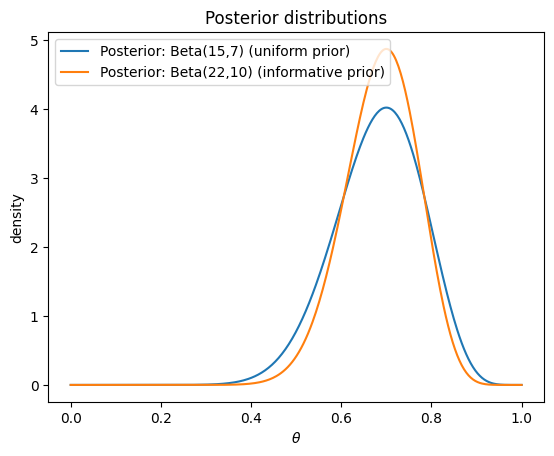

In [10]:
# Deliverable 1: plot both posteriors

# Grid
th = np.linspace(0, 1, 400)

# Uniform-prior posterior Beta(15,7)
post1 = beta.pdf(th, 15, 7)

# Informative-prior posterior Beta(22,10)
post2 = beta.pdf(th, 22, 10)

plt.plot(th, post1, label='Posterior: Beta(15,7) (uniform prior)')
plt.plot(th, post2, label='Posterior: Beta(22,10) (informative prior)')
plt.xlabel(r'$\theta$')
plt.ylabel('density')
plt.title('Posterior distributions')
plt.legend()
plt.show()


In [11]:
# Deliverable 2: summary table of posterior mean/variance/CI

summary = pd.DataFrame({
    'prior': ['Beta(1,1)', 'Beta(8,4)'],
    'posterior': ['Beta(15,7)', 'Beta(22,10)'],
    'mean': [mean_post, mean_post2],
    'variance': [var_post, var_post2],
    'CI95_low': [ci95[0], ci95_2[0]],
    'CI95_high': [ci95[1], ci95_2[1]],
})

summary


,prior,posterior,mean,variance,CI95_low,CI95_high
0,"Beta(1,1)","Beta(15,7)",0.681818,0.009432,0.478249,0.854123
1,"Beta(8,4)","Beta(22,10)",0.687500,0.006510,0.519639,0.833176


**Deliverable 3: interpretation (model answer)**

The informative prior $\mathrm{Beta}(8,4)$ has mean $8/(8+4)=2/3$, which already favors heads. After updating with the same data, its posterior $\mathrm{Beta}(22,10)$ is pulled slightly toward this prior mean and is narrower than the uniform‑prior posterior. By contrast, the uniform prior produces $\mathrm{Beta}(15,7)$, which is influenced only by the data. The predictive probabilities inherit these differences: the informative‑prior posterior yields a slightly higher $P(\text{H})$ and a more concentrated predictive distribution, while the uniform prior yields a broader predictive uncertainty.
